<a href="https://colab.research.google.com/github/marcosanaka/DesafioPythonBanco/blob/main/portifolio_RedesNeurais_e_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinando o modelo...
Treinamento concluído!


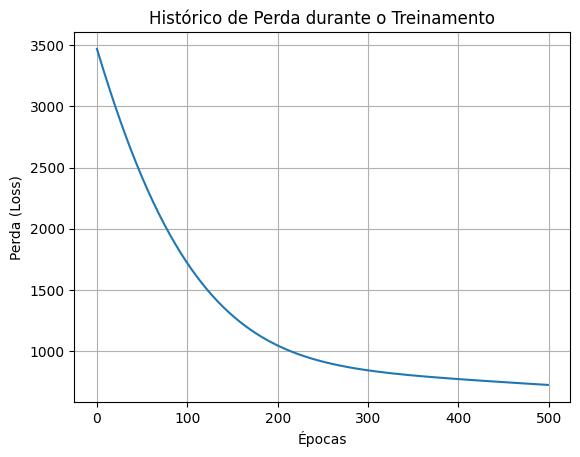

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

Comparativo entre modelo e fórmula real:
   Celsius  Fahrenheit Modelo  Fahrenheit Real
0    -30.0         -56.000000            -22.0
1    -20.0         -35.840000             -4.0
2      5.0          14.570000             41.0
3     10.0          24.650000             50.0
4     20.0          44.820000             68.0
5     25.0          54.900002             77.0
6     30.0          64.980003             86.0
7     35.0          75.059998             95.0
8     40.0          85.150002            104.0
9     50.0         105.309998            122.0


In [4]:
# Importações
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Preparação dos dados
# Dados de treinamento
celsius = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
fahrenheit = np.array([-40, 14, 32, 46.4, 59, 71.6, 100], dtype=float)

# Estrutura do modelo
# Modelo de rede neural simples
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])

# Compilando o modelo
model.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_squared_error')

# Treinando o modelo
print("Treinando o modelo...")
history = model.fit(celsius, fahrenheit, epochs=500, verbose=0)
print("Treinamento concluído!")

# Plot do histórico de perda
# Gráfico de Treinamento
plt.plot(history.history['loss'])
plt.title('Histórico de Perda durante o Treinamento')
plt.xlabel('Épocas')
plt.ylabel('Perda (Loss)')
plt.grid(True)
plt.show()

# Testando o modelo com novos valores
# Testes com Novas Temperaturas
novos_celsius = np.array([-30, -20, 5, 10, 20, 25, 30, 35, 40, 50], dtype=float)
previsoes_fahrenheit = model.predict(novos_celsius)

# Cálculo dos valores reais com a fórmula tradicional
valores_reais = (novos_celsius * 9/5) + 32

# Comparando resultados em uma tabela
tabela = pd.DataFrame({
    "Celsius": novos_celsius,
    "Fahrenheit Modelo": np.round(previsoes_fahrenheit.flatten(), 2),
    "Fahrenheit Real": np.round(valores_reais, 2)
})

print("\nComparativo entre modelo e fórmula real:")
print(tabela)
